<a href="https://colab.research.google.com/github/thakurakanksha288/learning_ml/blob/main/ml_chrun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# 01_understanding.ipynb
# ==========================================

import os
import pandas as pd
import numpy as np

# Load Data
raw_data_path = '/content/customer_churn_data.csv'
df = pd.read_csv(raw_data_path)

print("--- 1. First 5 Rows ---")
display(df.head())

print("\n--- 2. Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n--- 3. Column Data Types & Info ---")
df.info()

print("\n--- 4. Summary Statistics (Numerical) ---")
display(df.describe())

print("\n--- 5. Categorical Summary ---")
display(df.describe(include=['O']))

print("\n--- 6. Missing Values Check ---")
print(df.isnull().sum())

print("\n--- 7. Target Distribution (Churn) ---")
print(df['Churn'].value_counts(normalize=True) * 100)

--- 1. First 5 Rows ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes



--- 2. Dataset Shape ---
Rows: 5880, Columns: 21

--- 3. Column Data Types & Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5880 non-null   object 
 1   gender            5880 non-null   object 
 2   SeniorCitizen     5880 non-null   int64  
 3   Partner           5880 non-null   object 
 4   Dependents        5880 non-null   object 
 5   tenure            5880 non-null   int64  
 6   PhoneService      5880 non-null   object 
 7   MultipleLines     5880 non-null   object 
 8   InternetService   5880 non-null   object 
 9   OnlineSecurity    5880 non-null   object 
 10  OnlineBackup      5880 non-null   object 
 11  DeviceProtection  5880 non-null   object 
 12  TechSupport       5880 non-null   object 
 13  StreamingTV       5880 non-null   object 
 14  StreamingMovies   5880 non-null   object 
 15  Co

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.500680,36.549150,70.157779,2566.813165
std,0.500042,20.909674,28.804615,1910.017743
min,0.000000,1.000000,20.000000,20.030000
25%,0.000000,18.000000,45.717500,1020.217500
50%,1.000000,37.000000,70.155000,2136.445000
75%,1.000000,55.000000,95.457500,3767.665000
max,1.000000,72.000000,119.990000,8589.600000



--- 5. Categorical Summary ---


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880,5880
unique,5880,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,CUST5879,Male,Yes,No,Yes,No phone service,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,No
freq,1,2950,2995,3004,2941,2939,2029,2029,2029,2029,2029,2029,2029,2020,2990,1503,2982



--- 6. Missing Values Check ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- 7. Target Distribution (Churn) ---
Churn
No     50.714286
Yes    49.285714
Name: proportion, dtype: float64


In [3]:
# ==========================================
# 02_cleaning.ipynb
# ==========================================

import os
import pandas as pd
import numpy as np

# Load Raw Data
df = pd.read_csv('/content/customer_churn_data.csv')

# 1. Handle Whitespaces & Special Characters
# TotalCharges often contains whitespace strings (' ') in raw Telco datasets
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')

# 2. Impute Missing Values
# Fill TotalCharges with median or MonthlyCharges * tenure
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])

# 3. Handle Duplicate Records
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

# 4. Standardize Categorical Features
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# Normalize Binary / Text columns where applicable
if 'No internet service' in df.values:
    df = df.replace({'No internet service': 'No', 'No phone service': 'No'})

# 5. Outlier Inspection for Numerical Features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"IQR for {col}: {iqr:.2f}")

# 6. Save Cleaned Dataset
os.makedirs('../Data/Cleaned data', exist_ok=True)
df.to_csv('../Data/Cleaned data/cleaned_customer_churn_data.csv', index=False)
print("Cleaned data successfully saved to 'Data/Cleaned data/cleaned_customer_churn_data.csv'")

Duplicates found: 0
IQR for tenure: 37.00
IQR for MonthlyCharges: 49.74
IQR for TotalCharges: 2747.45
Cleaned data successfully saved to 'Data/Cleaned data/cleaned_customer_churn_data.csv'


In [4]:
# ==========================================
# 03_scenario_based.ipynb
# ==========================================

import pandas as pd

# Load Cleaned Data
df = pd.read_csv('/content/customer_churn_data.csv')

print("=== SCENARIO 1: High-Value Customer Risk Analysis ===")
# Define high-value customers as those with MonthlyCharges > 75th percentile
high_value_thresh = df['MonthlyCharges'].quantile(0.75)
high_value_df = df[df['MonthlyCharges'] >= high_value_thresh]
churn_rate_hv = (high_value_df['Churn'] == 'Yes').mean() * 100
print(f"High-Value Threshold: ${high_value_thresh:.2f}/month")
print(f"Churn Rate among High-Value Customers: {churn_rate_hv:.2f}%\n")

print("=== SCENARIO 2: Contract Type Impact on Retention ===")
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
display(contract_churn)

print("\n=== SCENARIO 3: Tenure Cohort Risk Analysis ===")
def tenure_group(tenure):
    if tenure <= 12:
        return '0-1 Year (New)'
    elif tenure <= 36:
        return '1-3 Years (Medium)'
    elif tenure <= 60:
        return '3-5 Years (Established)'
    else:
        return '5+ Years (Loyal)'

df['Tenure_Cohort'] = df['tenure'].apply(tenure_group)
cohort_analysis = df.groupby('Tenure_Cohort')['Churn'].value_counts(normalize=True).unstack() * 100
display(cohort_analysis)

print("\n=== SCENARIO 4: Tech Support & Senior Citizen Interaction ===")
tech_senior = df.groupby(['SeniorCitizen', 'TechSupport'])['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
print(tech_senior)

=== SCENARIO 1: High-Value Customer Risk Analysis ===
High-Value Threshold: $95.46/month
Churn Rate among High-Value Customers: 50.00%

=== SCENARIO 2: Contract Type Impact on Retention ===


Churn,No,Yes
Contract,,
Month-to-month,52.277228,47.722772
One year,49.539406,50.460594
Two year,50.262329,49.737671



=== SCENARIO 3: Tenure Cohort Risk Analysis ===


Churn,No,Yes
Tenure_Cohort,,
0-1 Year (New),52.443992,47.556008
1-3 Years (Medium),50.231125,49.768875
3-5 Years (Established),50.742448,49.257552
5+ Years (Loyal),49.899800,50.100200



=== SCENARIO 4: Tech Support & Senior Citizen Interaction ===
SeniorCitizen  TechSupport        
0              No                     49.792961
               No internet service    50.198807
               Yes                    48.547718
1              No                     50.207039
               No internet service    49.169110
               Yes                    47.748691
Name: Yes, dtype: float64


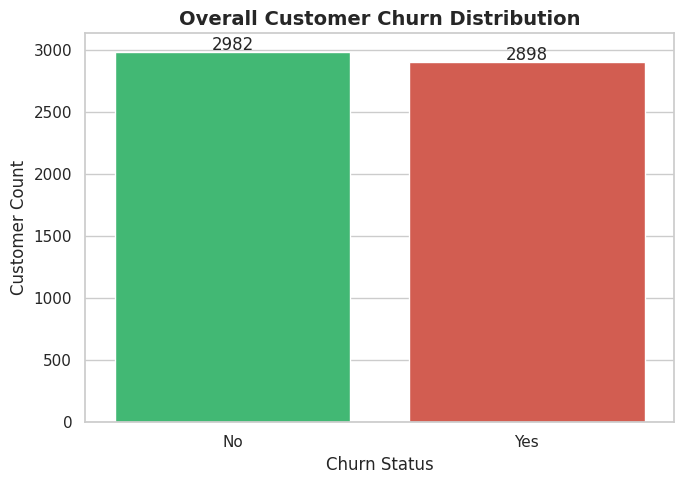

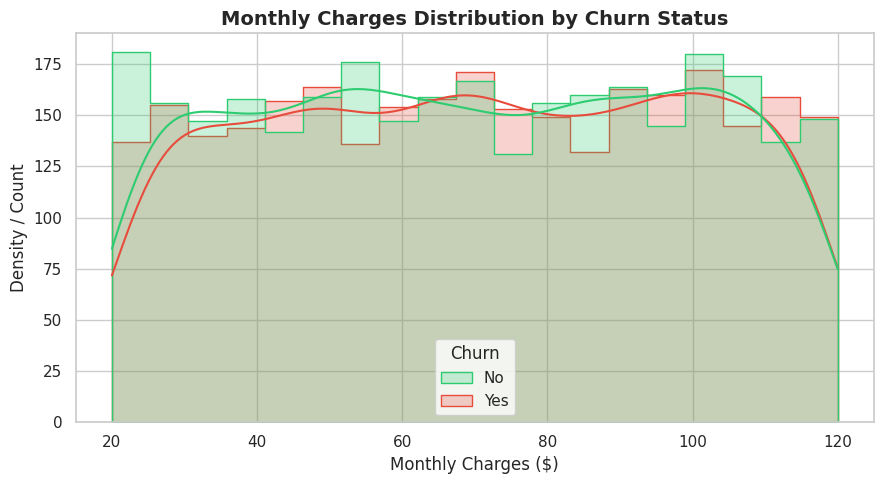

/tmp/ipykernel_2020/3253802592.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Contract', y=(df['Churn']=='Yes').astype(int), palette='Blues_d', errorbar=None)


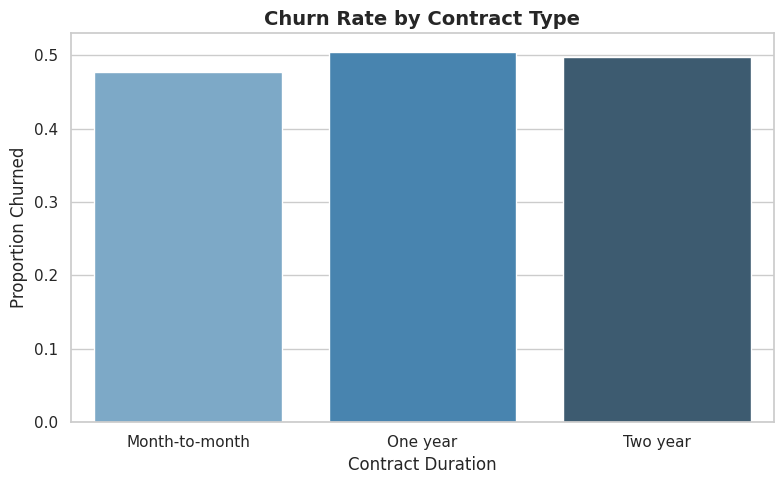

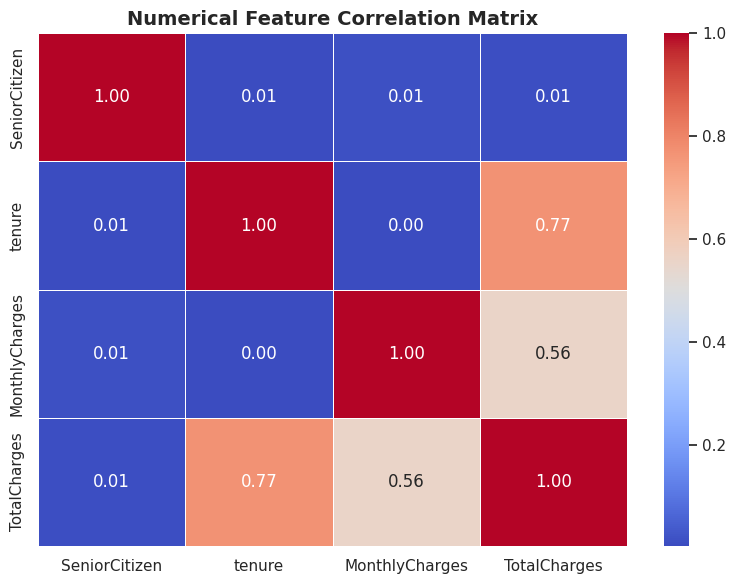

In [5]:
# ==========================================
# 04_charts_plots.ipynb
# ==========================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Config & Setup
os.makedirs('../Images', exist_ok=True)
df = pd.read_csv('/content/customer_churn_data.csv')
sns.set_theme(style="whitegrid", palette="muted")

# 1. Churn Class Distribution (Histogram/Bar Chart)
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Customer Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig('../Images/01_churn_distribution.png', dpi=300)
plt.show()

# 2. Histogram: Monthly Charges Distribution by Churn
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element="step", palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Density / Count')
plt.tight_layout()
plt.savefig('../Images/02_monthly_charges_histogram.png', dpi=300)
plt.show()

# 3. Bar Chart: Churn Rate by Contract Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Contract', y=(df['Churn']=='Yes').astype(int), palette='Blues_d', errorbar=None)
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.ylabel('Proportion Churned')
plt.xlabel('Contract Duration')
plt.tight_layout()
plt.savefig('../Images/03_churn_by_contract.png', dpi=300)
plt.show()

# 4. Heatmap: Correlation Matrix of Numerical Features
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Images/04_correlation_heatmap.png', dpi=300)
plt.show()

In [2]:
import os
import pandas as pd
import numpy as np

# Set console display settings for clean table formatting
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Load data dynamically relative to script location
# BASE_DIR = os.path.dirname(os.path.abspath(__file__))
CLEAN_PATH = '/content/cleaned_customer_churn_data.csv'

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
    print("✓ Loaded Cleaned Data successfully.")
else:
    RAW_PATH = '/content/customer_churn_data.csv'
    df = pd.read_csv(RAW_PATH)
    # Preprocessing fallback
    if 'TotalCharges' in df.columns:
        df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(' ', np.nan), errors='coerce')
        df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'])
    print("! Cleaned file not found. Loaded Raw Data directly.")

print("\n" + "=" * 70)
print("             CUSTOMER CHURN SCENARIO ANALYSIS REPORT")
print("=" * 70)

# Helper function to compute churn percentage metrics
def summarize_churn(data, groupby_col):
    summary = data.groupby(groupby_col).agg(
        Total_Customers=('customerID', 'count'),
        Churned_Count=('Churn', lambda x: (x == 'Yes').sum()),
        Retained_Count=('Churn', lambda x: (x == 'No').sum()),
        Churn_Rate_Pct=('Churn', lambda x: round((x == 'Yes').mean() * 100, 2)),
        Avg_Monthly_Bill=('MonthlyCharges', 'mean')
    )
    return summary

# ==============================================================================
# SCENARIO 1: Price Sensitivity & Spend Level Analysis
# ==============================================================================
print("\n--- SCENARIO 1: Price Sensitivity & Spend Level Analysis ---")
median_spend = df['MonthlyCharges'].median()

# Segment into Spend Tiers relative to Median
df['Spend_Category'] = np.where(
    df['MonthlyCharges'] >= median_spend,
    'High Spend (>= Median)',
    'Low Spend (< Median)'
)

s1_result = summarize_churn(df, 'Spend_Category')
print(s1_result)

# ==============================================================================
# SCENARIO 2: Contract Commitment & Retention Analysis
# ==============================================================================
print("\n--- SCENARIO 2: Contract Commitment & Retention Analysis ---")

s2_result = summarize_churn(df, 'Contract')
s2_result['Avg_Tenure_Months'] = df.groupby('Contract')['tenure'].mean().round(1)
print(s2_result[['Total_Customers', 'Churned_Count', 'Churn_Rate_Pct', 'Avg_Tenure_Months', 'Avg_Monthly_Bill']])

# ==============================================================================
# SCENARIO 3: Customer Lifecycle & Tenure Cohort Analysis
# ==============================================================================
print("\n--- SCENARIO 3: Customer Lifecycle & Tenure Cohort Analysis ---")

def assign_tenure_cohort(months):
    if months <= 12:
        return '01. New (0-1 Year)'
    elif months <= 36:
        return '02. Established (1-3 Years)'
    elif months <= 60:
        return '03. Mature (3-5 Years)'
    else:
        return '04. Highly Loyal (5+ Years)'

df['Tenure_Cohort'] = df['tenure'].apply(assign_tenure_cohort)

s3_result = summarize_churn(df, 'Tenure_Cohort')
s3_result['Avg_Total_Revenue'] = df.groupby('Tenure_Cohort')['TotalCharges'].mean().round(2)
print(s3_result)

# ==============================================================================
# SCENARIO 4: Extreme Churn Risk Profiling Analysis
# ==============================================================================
print("\n--- SCENARIO 4: Extreme Churn Risk Profiling Analysis ---")

high_risk_cond = (df['Contract'] == 'Month-to-month') & (df['MonthlyCharges'] >= median_spend)
low_risk_cond = (df['Contract'] == 'Two year') & (df['MonthlyCharges'] < median_spend)

high_risk_group = df[high_risk_cond]
low_risk_group = df[low_risk_cond]

s4_comparison = pd.DataFrame([
    {
        'Profile_Name': 'High Risk (Month-to-Month + High Spend)',
        'Customer_Count': len(high_risk_group),
        'Churned_Count': (high_risk_group['Churn'] == 'Yes').sum(),
        'Churn_Rate_Pct': round((high_risk_group['Churn'] == 'Yes').mean() * 100, 2),
        'Avg_Monthly_Bill ($)': round(high_risk_group['MonthlyCharges'].mean(), 2)
    },
    {
        'Profile_Name': 'Low Risk (Two-Year + Low Spend)',
        'Customer_Count': len(low_risk_group),
        'Churned_Count': (low_risk_group['Churn'] == 'Yes').sum(),
        'Churn_Rate_Pct': round((low_risk_group['Churn'] == 'Yes').mean() * 100, 2),
        'Avg_Monthly_Bill ($)': round(low_risk_group['MonthlyCharges'].mean(), 2)
    }
])

print(s4_comparison.to_string(index=False))

! Cleaned file not found. Loaded Raw Data directly.

             CUSTOMER CHURN SCENARIO ANALYSIS REPORT

--- SCENARIO 1: Price Sensitivity & Spend Level Analysis ---
                        Total_Customers  Churned_Count  Retained_Count  Churn_Rate_Pct  Avg_Monthly_Bill
Spend_Category                                                                                          
High Spend (>= Median)             2940           1462            1478           49.73         95.089344
Low Spend (< Median)               2940           1436            1504           48.84         45.226214

--- SCENARIO 2: Contract Commitment & Retention Analysis ---
                Total_Customers  Churned_Count  Churn_Rate_Pct  Avg_Tenure_Months  Avg_Monthly_Bill
Contract                                                                                           
Month-to-month             2020            964           47.72               36.6         70.700748
One year                   1954            986    